In [3]:

import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [4]:
pmf = [];
rho = [];
bia = [];
rows = [];
cols = [];

nb=8

for i in range(nb):
    pmf += [np.loadtxt("../wham-0126-blocks/pmf-%d.dat" % (i+1))];
    rho += [np.loadtxt("../wham-0126-blocks/rho-%d.dat" % (i+1))];
    bia += [np.loadtxt("../wham-0126-blocks/bia-%d.dat" % (i+1))];
    
    rows = np.unique(np.append(rows, np.unique(pmf[i][:,0])));
    cols = np.unique(np.append(cols, np.unique(pmf[i][:,1])));

pmf_array = np.zeros((nb,len(rows),len(cols)))
rho_array =np.zeros((nb,len(rows),len(cols)))
bia_array = np.zeros((nb,len(rows),len(cols)))

for i, angle in enumerate(rows):
    for j, dist in enumerate(cols):
        for k in range(nb):
            l = np.intersect1d(np.where(pmf[k][:,0] == angle), np.where(pmf[k][:,1] == dist));
            if (l.size > 0):
                pmf_array[k,i,j] = pmf[k][l,2]
                bia_array[k,i,j] = bia[k][l,2]
                rho_array[k,i,j] = rho[k][l,2]

for k in range(nb):
    pmf_array[k] -= np.min(pmf_array[k,9:-5,2:-2])

/tmp/ipykernel_3543468/3771911029.py:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  pmf_array[k,i,j] = pmf[k][l,2]
/tmp/ipykernel_3543468/3771911029.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bia_array[k,i,j] = bia[k][l,2]
/tmp/ipykernel_3543468/3771911029.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  rho_array[k,i,j] = rho[k][l,2]


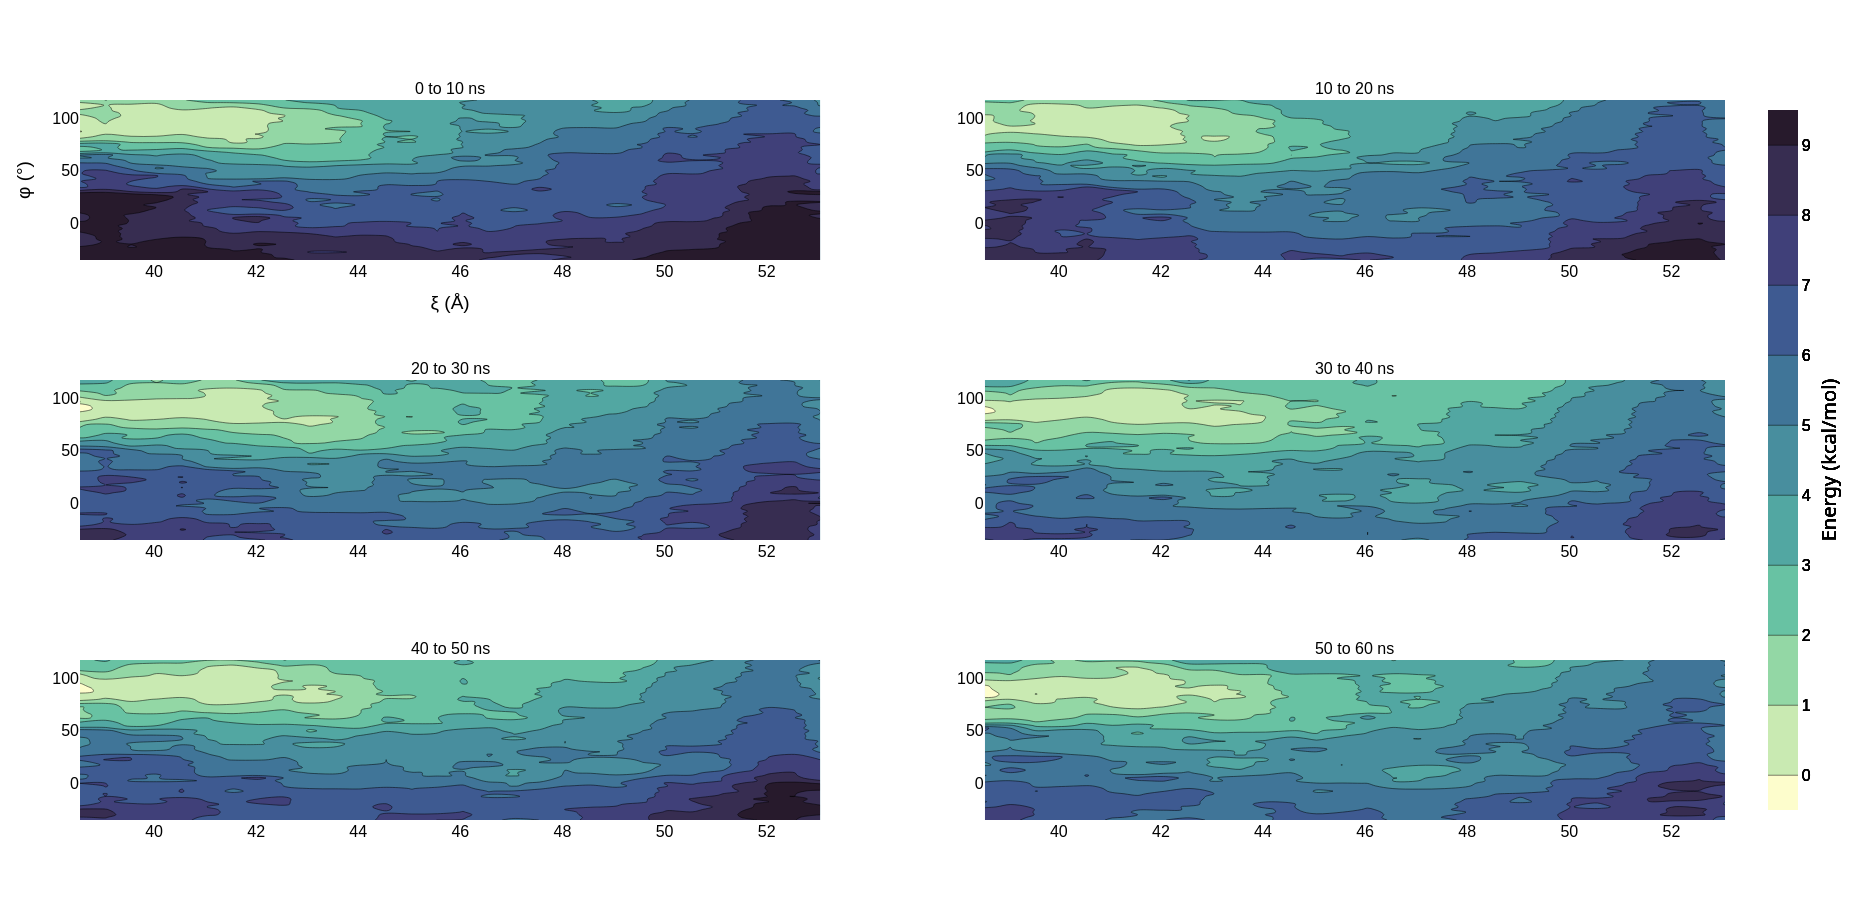

In [5]:
nb=8
fig = make_subplots(rows=3,cols=2, subplot_titles=["%d to %d ns" % (_*10, (_+1)*10) for _ in range(nb)])
for i in range(nb-2):
    fig.add_trace(go.Contour(z=pmf_array[i+2,10:-5,:-1],x=cols[2:-2],y=rows[10:-5], \
                             contours=dict(start=0,end=9,size=1),colorscale='deep', \
                                                  colorbar=dict(
            title='Energy\n(kcal/mol)', # title here
            titleside='right',
            titlefont=dict(
                size=20,
                family='Arial Black, sans-serif',
            color='black'))), \
                             row=1+int(i/2),col=1+i%2)
    
 #   fig.update_xaxes(title_text="ψ (Å)",row=1+int(i/2),col=i%2+1)
fig['layout'].update(width=600,height=900)
fig.update_layout(
    xaxis_title="ξ (Å)",
    yaxis_title="φ (°)",
    font=dict(size=16,family='Arial',color='black'),
    showlegend=False
)
fig.show()
#fig.write_image("blocks.svg")

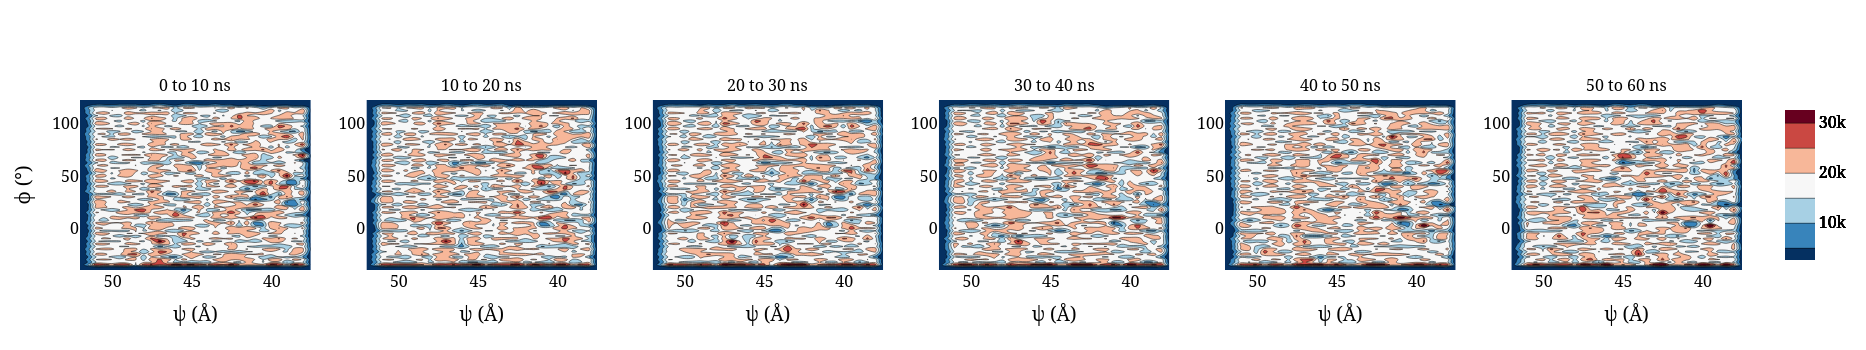

In [6]:
nb=8
fig = make_subplots(rows=1,cols=nb-2, subplot_titles=["%d to %d ns" % (_*10, (_+1)*10) for _ in range(nb)])
for i in range(nb-2):
    fig.add_trace(go.Contour(z=bia_array[i+2,8:-3,:-1],x=cols[:-1],y=rows[8:-3], \
                             contours=dict(start=5000,end=30000,size=5000),colorscale='RdBu_r'), \
                             row=1,col=i+1)
    
    fig.update_xaxes(title_text="ψ (Å)",autorange='reversed',row=1,col=i+1)
fig['layout'].update(width=1200,height=350)
fig.update_layout(
    xaxis_title="ψ (Å)",
    yaxis_title="ϕ (°)",
    font=dict(size=16,family='Arial Black',color='black'),
    showlegend=False
)
fig.show()

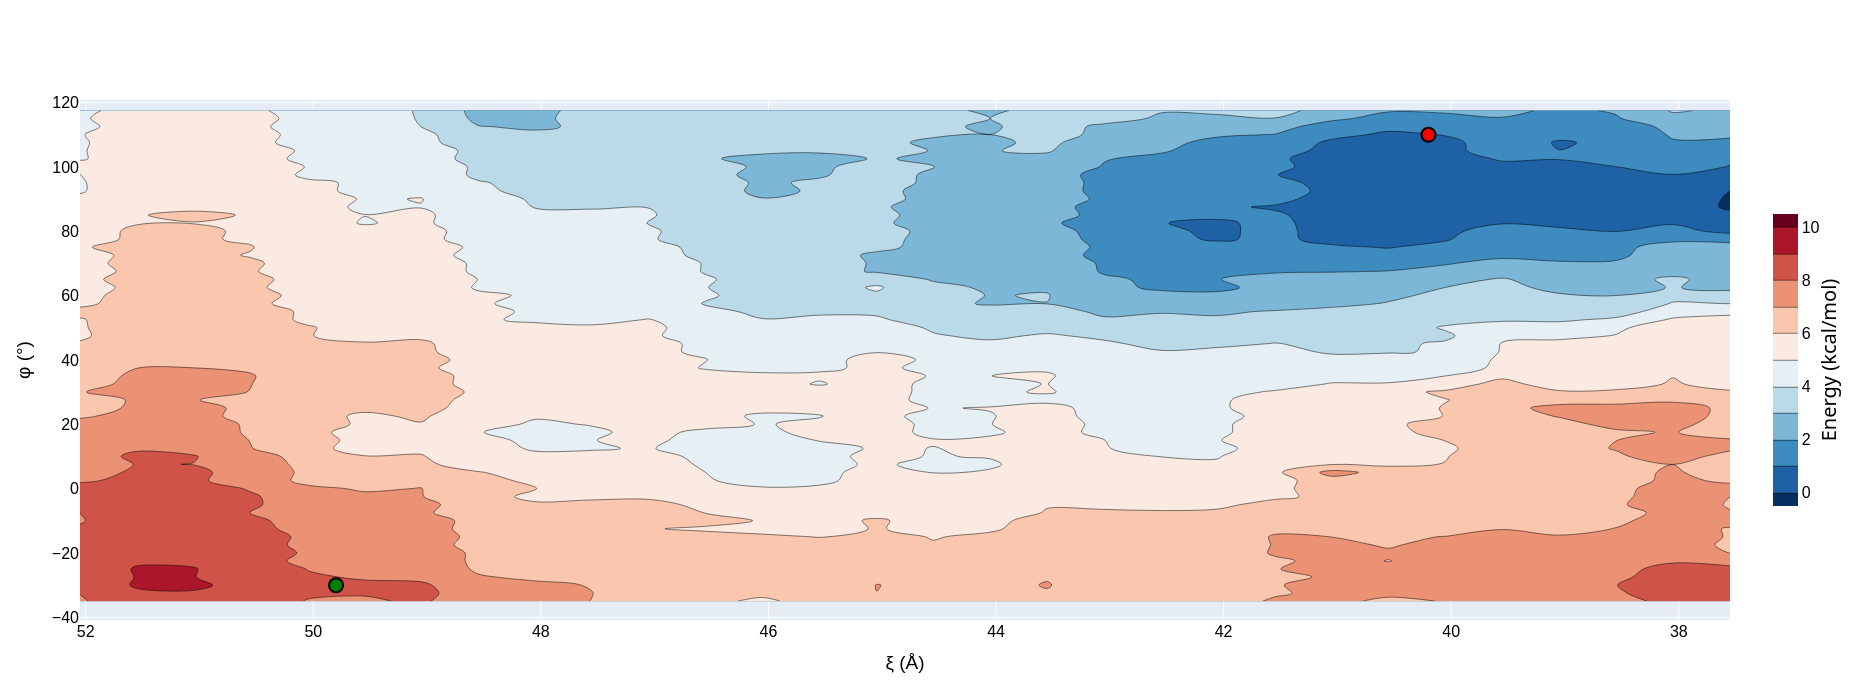

In [7]:
fig = go.Figure( \
    data = go.Contour( \
        z=np.mean(pmf_array[2:,10:-5,:-1],axis=0),
        x=cols[:-1], y=rows[10:-5],
                     contours=dict(
            start=0,
            end=10,
            size=1),
                      colorscale='RdBu',
                      reversescale=True,
                      colorbar=dict(
            title='Energy\n(kcal/mol)', # title here
            titleside='right',
            titlefont=dict(
                size=20,
                family='Arial Black, sans-serif',
            color='black'),
            thickness=25,
            thicknessmode='pixels',
            len=0.6,
            lenmode='fraction',
            outlinewidth=0)));
fig.update_layout(
    xaxis_title="ξ (Å)",
    yaxis_title="φ (°)",
    font=dict(size=16,family='Arial',color='black'),
    showlegend=False
)
fig['layout'].update(width=700,height=700)
fig.update_xaxes(autorange='reversed')
fig.add_trace(go.Scatter(x=[40.2,49.8], y=[110,-30],
                    mode='markers',marker=dict(
            color=['red','green'], 
            size=14,
            line=dict(
                color='black',
                width=2
            )
        )))
#fig.add_trace(go.Scatter(x=[16.8,20,23,30, 31.4], y=[110,80,60,30,-30],
#                    mode='lines', line_shape='spline', line=dict(
#                color='black',
#                width=2, dash='dash'
#            )
#        ))
fig.show()
# ax.clabel(CS,fontsize=10)
# ax.set_xticks(ticks=range(len(cols)),labels=cols);
# ax.set_yticks(ticks=range(len(rows)),labels=rows);
# ax.set_xlabel("Distance colvar")
# ax.set_ylabel("Angle colvar")
# ax.set_title("Potential of mean force mean")

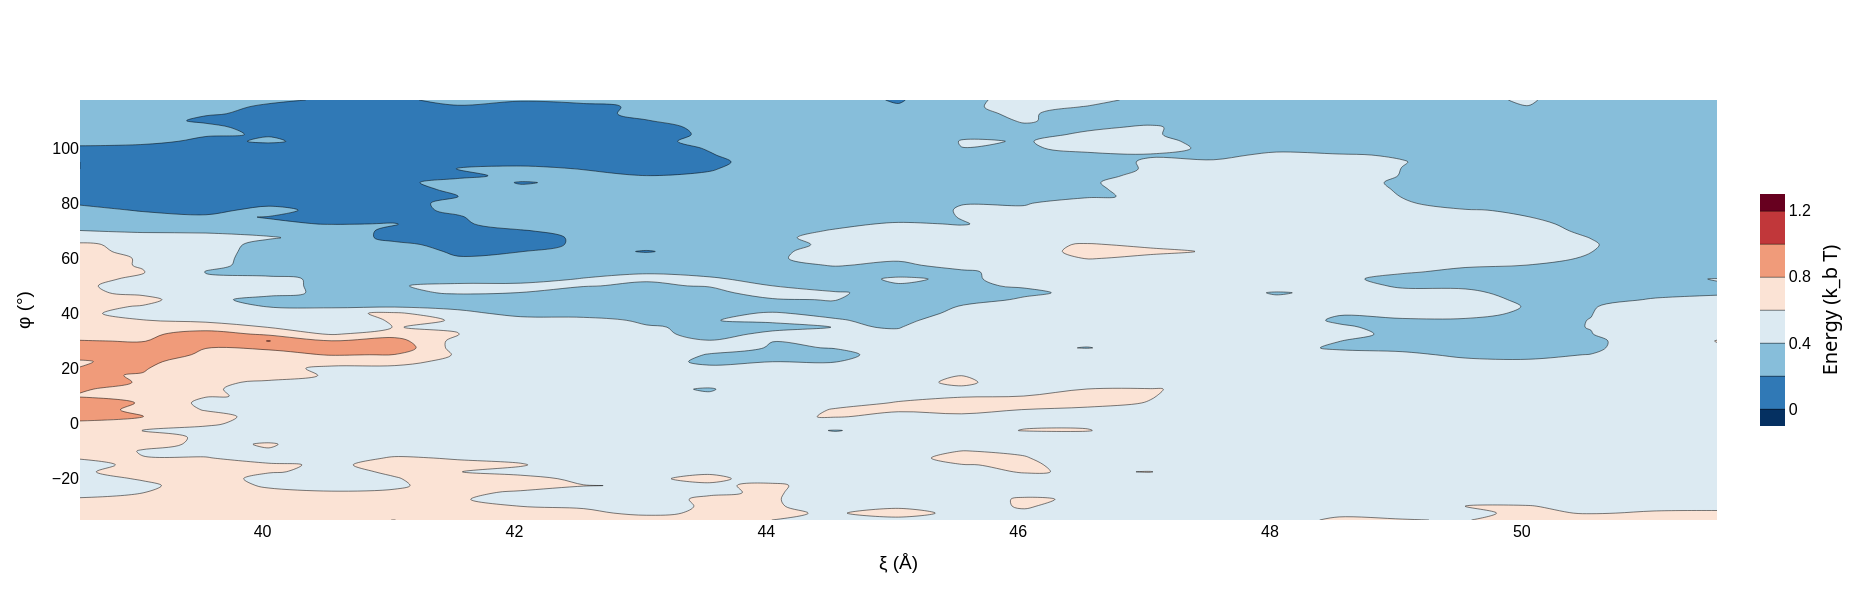

In [8]:
pmf_array[np.where(pmf_array==np.inf)]=0
kbt = 0.001987 * 310
nb=6
fig = go.Figure( \
    data = go.Contour( \
        z=np.std(pmf_array[(8-nb):],axis=0)[10:-5,2:-2]/np.sqrt(nb)/kbt,
        x=cols[2:-2], y=rows[10:-5],
                     contours=dict(
            start=0,
            end=1.2,
            size=0.2),
                      colorscale='RdBu',
                      reversescale=True,
                      colorbar=dict(
            title='Energy\n(k_b T)', # title here
            titleside='right',
            titlefont=dict(
                size=20,
                family='Arial Black, sans-serif',
            color='black'),
            thickness=25,
            thicknessmode='pixels',
            len=0.6,
            lenmode='fraction',
            outlinewidth=0)));
fig.update_layout(
    xaxis_title="ξ (Å)",
    yaxis_title="φ (°)",
    font=dict(size=16,family='Arial',color='black'),
    showlegend=False
)
fig['layout'].update(width=600,height=600)
fig.show()
#fig.write_image('se.svg')
# ax.clabel(CS,fontsize=10)
# ax.set_xticks(ticks=range(len(cols)),labels=cols);
# ax.set_yticks(ticks=range(len(rows)),labels=rows);
# ax.set_xlabel("Distance colvar")
# ax.set_ylabel("Angle colvar")
# ax.set_title("Potential of mean force mean")

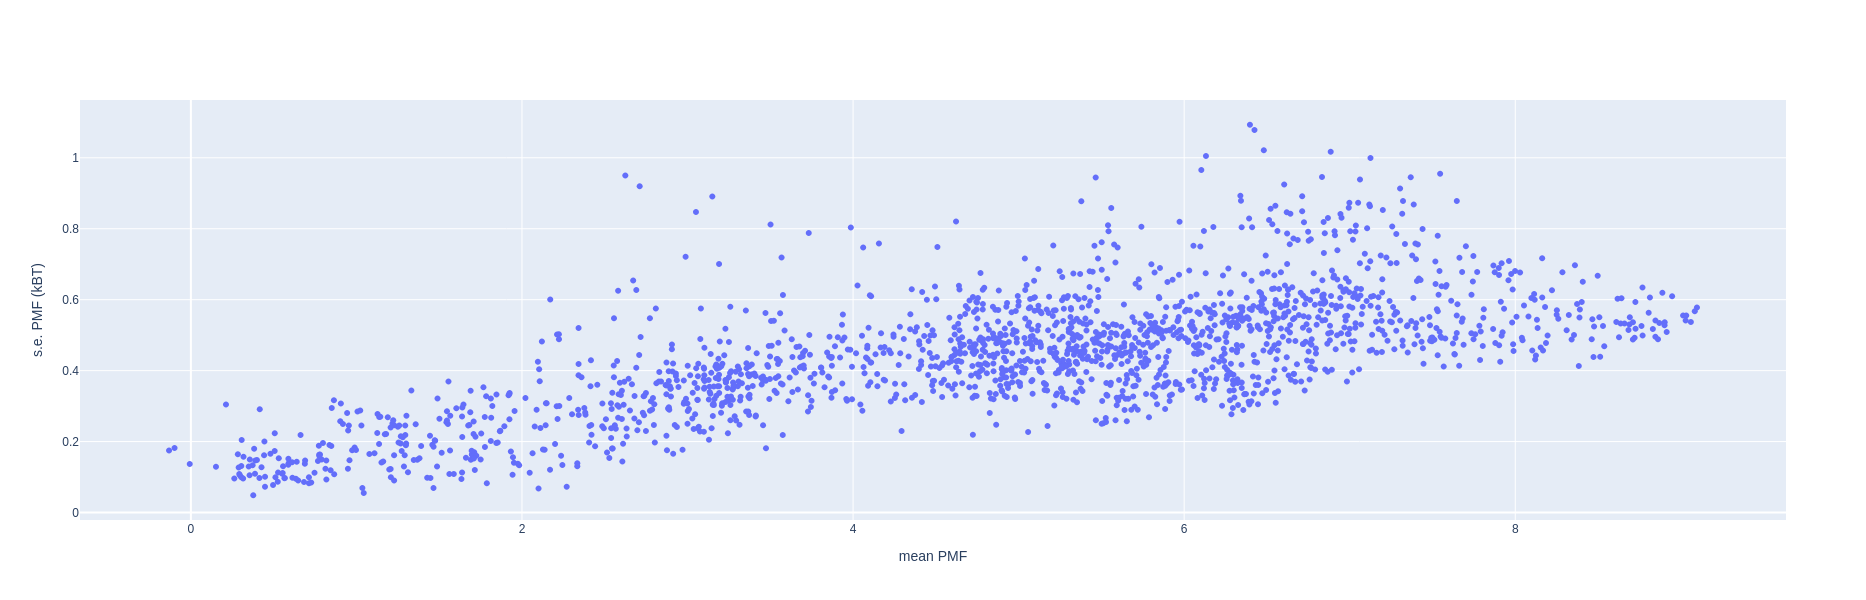

In [9]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=np.mean(pmf_array[2:,10:-5,:-1],axis=0).reshape(-1),y=np.std(pmf_array[2:],axis=0)[10:-5,:-1].reshape(-1)/np.sqrt(nb)/kbt,mode=
                        'markers'))
fig.update_layout(height=600,width=600,xaxis_title='mean PMF',yaxis_title='s.e. PMF (kBT)')